In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [124]:
def getCSV(csv):
    dfl = pd.read_csv(csv)
    return dfl
df = getCSV(r'C:\Users\Tom\OneDrive\Documents\APROJECTS\AirSeaArrivals-Updated.csv') 
print(list(set(df['Country'])))

['Belgium', 'Germany', 'Poland', 'France', 'Italy', 'Selected EU (AT,BG,CY,CZ,DK,EE,FI,GR,HR,HU,LT,LU,LV,MT,RO,SE,SI,SK)', 'Other Transatlantic Countries(1)', 'Other Countries(42)', 'Other UK (1)', 'All countries', 'Spain', 'Switzerland', 'Great Britain', 'Other Europe (34)', 'United Arab Emirates', 'Netherlands', 'Portugal', 'United States']


In [125]:
direction = "Arrivals"
year = '2010 June'

filtered_df = df[df['Direction']==direction]
filtered_df = filtered_df[filtered_df['Country']!='All countries']
filtered_df = filtered_df[filtered_df['Country']!='Other UK (1)']
filtered_df = filtered_df[filtered_df['Month'].str.contains(year)]

In [126]:
def changeNames(name):
    switch = {
        "Selected EU (AT,BG,CY,CZ,DK,EE,FI,GR,HR,HU,LT,LU,LV,MT,RO,SE,SI,SK)": "Other EU",
        "Other Transatlantic Countries(1)": "Other \nTransatlantic",
        "United Arab Emirates": "UAE",
        "Other Europe (34)": "Other Europe",
        "Other Countries(42)": "Other"
    }
    if name not in switch:
        return name
    else:
        return switch[name]
        

filtered_df['Country'] =  filtered_df['Country'].apply(changeNames)

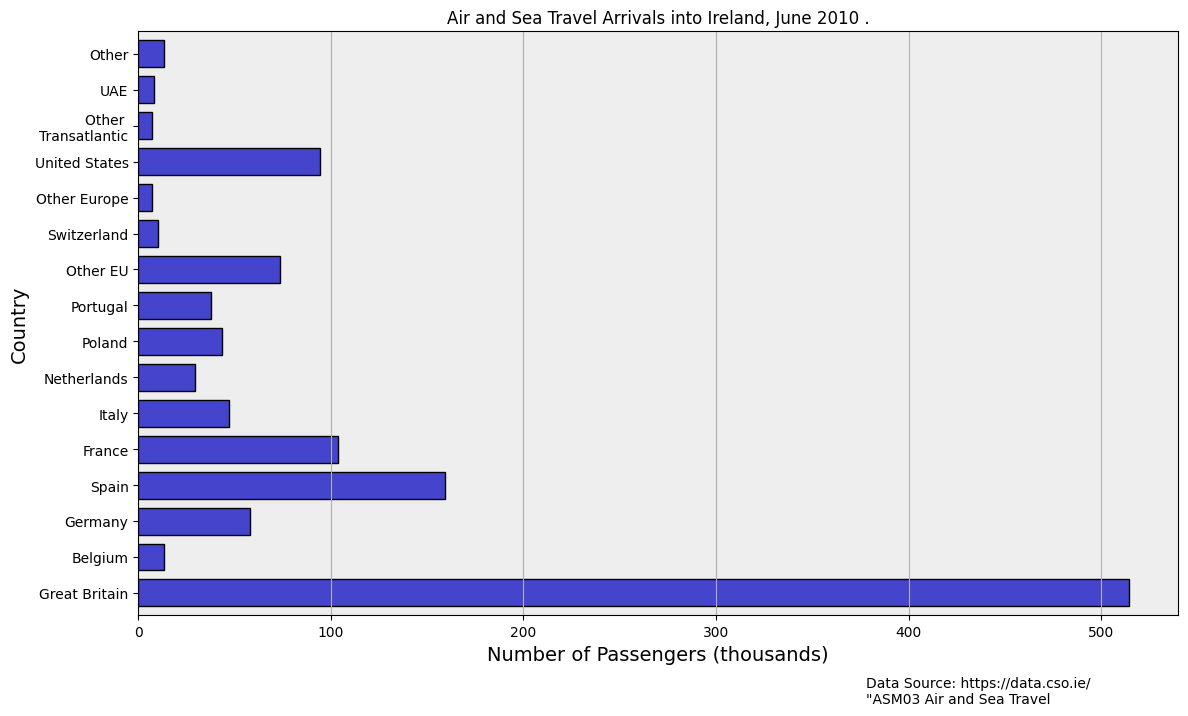

In [127]:
fig, ax = plt.subplots(1, 1, figsize=(13, 8))

filtered_df.plot(x="Country", y="VALUE", kind="barh", width=0.75, edgecolor="black", color="#44C", ax=ax)

title_string = "Air and Sea Travel Arrivals into Ireland, "+year[5:]+" "+year[:5]+"."

plt.title(title_string)
plt.xlabel('Number of Passengers (thousands)', fontsize=14)
plt.ylabel('Country', fontsize=14)
plt.xticks(rotation=0) 
#ax.set_xlim(200,550)
ax.set_facecolor('#EEEEEE') 
ax.get_legend().remove()
plt.grid(True, axis="x")

plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.17)
plt.text(0.7, -0.15, "Data Source: https://data.cso.ie/ \n\"ASM03 Air and Sea Travel", ha='left', transform=ax.transAxes)

save_fig = 'Arrivals-'+year+'.png'
plt.savefig(save_fig)

# Show the plot
plt.show()


         STATISTIC Label          Month               Country   Direction  \
0     Air and Sea Travel   2010 January         Great Britain    Arrivals   
1     Air and Sea Travel   2010 January         Great Britain  Departures   
2     Air and Sea Travel   2010 January          Other UK (1)    Arrivals   
3     Air and Sea Travel   2010 January          Other UK (1)  Departures   
4     Air and Sea Travel   2010 January               Belgium    Arrivals   
...                  ...            ...                   ...         ...   
6547  Air and Sea Travel  2025 February  United Arab Emirates  Departures   
6548  Air and Sea Travel  2025 February   Other Countries(42)    Arrivals   
6549  Air and Sea Travel  2025 February   Other Countries(42)  Departures   
6550  Air and Sea Travel  2025 February         All countries    Arrivals   
6551  Air and Sea Travel  2025 February         All countries  Departures   

          UNIT   VALUE  
0     Thousand   361.5  
1     Thousand   407.6  


In [103]:
filtered_df = df[(df['Country']=='All countries')&(df['Month'].str.contains("2024|2023|2022"))]
arrivals_df = filtered_df[filtered_df['Direction']=='Arrivals']
departures_df = filtered_df[filtered_df['Direction']=='Departures']

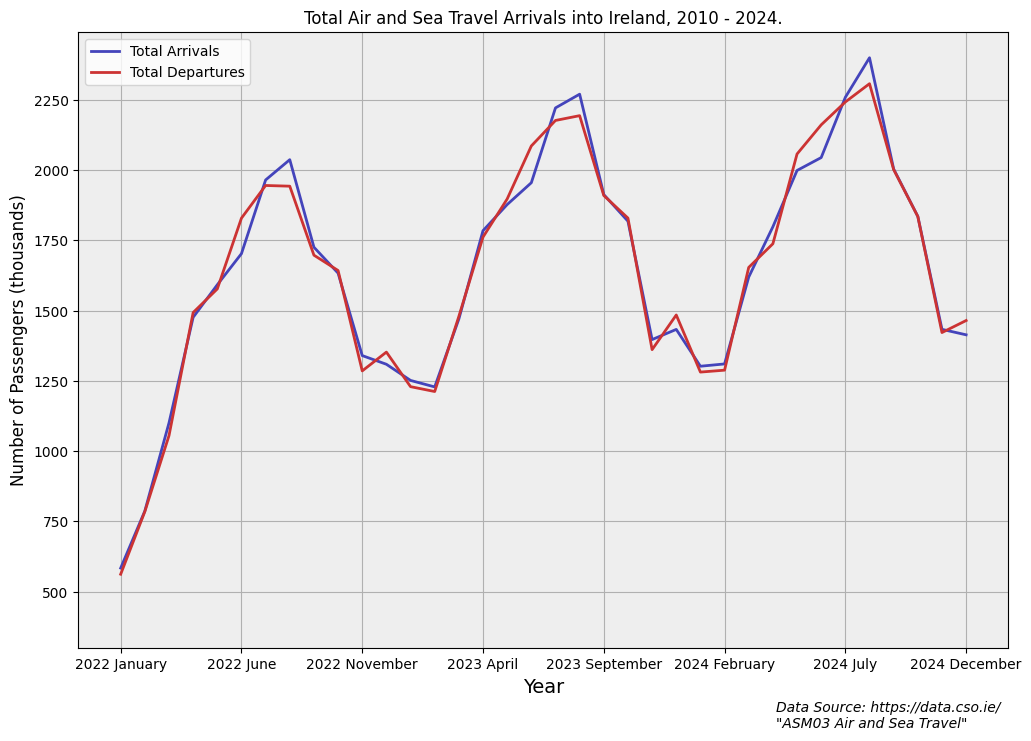

In [107]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

arrivals_df.plot(x="Month", y="VALUE", kind="line", marker="None", linestyle="-", color="#44B", linewidth=2, ax=ax, label="Total Arrivals")
departures_df.plot(x="Month", y="VALUE", kind="line", marker="None", linestyle="-", color="#C33", linewidth=2, ax=ax, label="Total Departures")

title_string = "Total Air and Sea Travel Arrivals into Ireland, 2010 - 2024."

plt.title(title_string)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Number of Passengers (thousands)', fontsize=12)
ax.set_ylim(300)
ax.set_facecolor('#EEEEEE') 
plt.grid(True)

plt.text(0.75, -0.13, "Data Source: https://data.cso.ie/ \n\"ASM03 Air and Sea Travel\" ", ha='left',
         transform=ax.transAxes, fontdict={'fontstyle': 'italic', 'fontsize': 10})

save_fig = 'Total-Arrivals-2022-2024.png'
plt.savefig(save_fig, bbox_inches="tight")

# Show the plot
plt.show()